# Travel Insurance Prediction
## Supervised Machine Learning Fundamentals


- **Author:** Hussein Loubani
- **Dataset:** Travel Insurance Prediction, Tour & Travels Company (2019)
- **Target:** `TravelInsurance` (binary: 1 = purchased, 0 = not purchased)
- **Task type:** Binary classification (predictive modelling)

---

### Table of Contents

1. Imports and Setup
2. Problem Definition
3. Data Loading and First Audit
4. Data Cleaning
5. Train / Test Split
6. Exploratory Data Analysis
7. Statistical Inference
8. Preprocessing Strategy
9. Baseline Models
10. Model Comparison with Cross-Validation
11. Hyperparameter Tuning
12. Final Test Evaluation
13. Error Analysis and Interpretation
14. Conclusion, Limitations, and Recommendations


---
## 1. Imports and Setup


In [1]:
# Standard library
import sys
import warnings
from pathlib import Path

# Third-party
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# sklearn preprocessing & pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# sklearn dimensionality reduction & feature selection
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.manifold import TSNE

# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

# Local project modules
_root = next(
    (p for p in [Path.cwd()] + list(Path.cwd().parents)
     if (p / "travel_insurance").is_dir()),
    Path.cwd().parent,  # fallback
)
sys.path.insert(0, str(_root))

from travel_insurance.config import (
    RANDOM_SEED,
    ALPHA,
    TARGET,
    CATEGORICAL_FEATURES,
    NUMERICAL_FEATURES,
    ALL_FEATURES,
    PALETTE,
    LR_GRID, NB_GRID, KNN_GRID, SVM_GRID,
)
from travel_insurance.dataset import (
    load_data,
    audit_data,
    anomaly_screen,
    descriptive_stats,
    target_distribution,
    inspect_categoricals,
    duplicate_summary,
    duplicate_impact_numerical,
    duplicate_impact_categorical,
    drop_duplicates_clean,
    split_data,
)
from travel_insurance.features import (
    NUMERICAL_SCALE, BINARY_INT_PASS, BINARY_ORDINAL, NOMINAL_OHE,
    ENG_NUM_SCALE, ENG_NUM_PASS, ENG_BIN_ORDINAL, ENG_NOMINAL_OHE, ENG_FEATURES,
    build_preprocessor, make_pipeline,
    add_engineered_features, build_eng_preprocessor, make_eng_pipeline,
)
from travel_insurance.statistics import (
    two_sample_ttest,
    two_proportion_ztest,
    print_test_result,
)
from travel_insurance.modeling.train import cv_compare
from travel_insurance.modeling.predict import evaluate_model, compare_final_metrics
from travel_insurance.plots import (
    apply_global_style,
    plot_target_distribution,
    plot_stratification_check,
    plot_numerical_distributions,
    plot_categorical_distributions,
    plot_boxplots_by_target,
    plot_correlation_heatmap,
    plot_income_age_scatter,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_pr_curves,
    plot_cv_comparison,
    plot_learning_curve,
    save_figure,
)

# Paths
DATA_PATH    = Path.cwd().parent / "data" / "raw" / "TravelInsurancePrediction.csv"
FIGURES_DIR  = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Global settings
warnings.filterwarnings("ignore")
apply_global_style()
np.random.seed(RANDOM_SEED)

print("Environment ready.")

Environment ready.


---
## 2. Problem Definition

### Business context:

A tour and travel company offered a travel insurance package to ~2,000 customers in 2019. The goal is to build a classifier that predicts whether a given customer will purchase the insurance, based on demographic and travel-history features. The use case is customer-specific advertising: correctly identifying likely buyers allows the company to target marketing spend efficiently. 

This is a **predictive** modelling task, not an explanatory one. Coefficients and feature importances are interpreted as associations in the training data, not as causal mechanisms. The company's dataset is observational, customers were not randomly assigned to treatment groups.

### Machine Learning formulation:

| | |
|---|---|
| **Problem type** | Binary classification |
| **Target** | `TravelInsurance` (1 = purchased, 0 = did not purchase) |
| **Features** | 8 customer attributes (age, income, employment, education, family size, health, travel history) |
| **Primary metric** | ROC-AUC: measures rank discrimination across all thresholds, robust to class imbalance |
| **Secondary metrics** | PR-AUC, F1-score, Recall, Precision, Balanced Accuracy |
| **Baseline** | Majority-class dummy (always predict 0) and logistic regression (linear baseline) |

### Why ROC-AUC?

With a 35.7% positive rate, raw accuracy is unreliable: a constant-negative classifier scores 64.3% while providing no discriminative signal. ROC-AUC evaluates whether the model ranks positive cases above negative cases across all decision thresholds. PR-AUC supplements this by emphasising performance on the minority class.

### Precision-recall tradeoff:

- **High recall (low threshold)**: captures more true buyers, but increases false positives and outreach cost.
- **High precision (high threshold)**: reduces wasted contacts, but risks missing genuine buyers.

The optimal threshold depends on the relative cost of a missed sale vs. a wasted contact, which is a business decision outside the scope of this analysis.

---
## 3. Data Loading and First Audit

### 3.1 Load Data

In [2]:
df = load_data(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 1,987 rows × 9 columns


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


### 3.2 Variable Glossary

| Column | Type | Description |
|---|---|---|
| `Age` | Numeric int | Customer age in years |
| `Employment Type` | nominal two-level categorical | `Government Sector` or `Private Sector/Self Employed` |
| `GraduateOrNot` | Binary string | Whether the customer is a college graduate (`Yes`/`No`) |
| `AnnualIncome` | Numeric int | Annual income in Indian Rupees, rounded to nearest ₹50,000 |
| `FamilyMembers` | Numeric int | Number of family members |
| `ChronicDiseases` | Binary int | 1 = has a chronic condition (diabetes, hypertension, asthma etc.) |
| `FrequentFlyer` | Binary string | Derived from ≥4 flight bookings in 2017–2019 (`Yes`/`No`) |
| `EverTravelledAbroad` | Binary string | Has the customer ever travelled internationally? (`Yes`/`No`) |
| `TravelInsurance` | Binary int | **Target**: 1 = purchased the 2019 package, 0 = did not |

- Income is rounded to the nearest ₹50,000, so there is granularity loss, not actual rounding error.
- `FrequentFlyer` is a derived label, not a raw booking count, and the exact derivation logic is not available, so we treat it as a reliable binary signal.
- All data is from 2019, so customer behaviour may have shifted significantly post-pandemic.

### 3.3 Audit Data

In [3]:
summary = audit_data(df)
summary

Shape          : 1,987 rows x 9 columns
Duplicated rows: 738

Missing values : None detected.



,dtype,n_unique,missing,min,max,mean,median
column,,,,,,,
Age,int64,11,0,25,35,29.65,29.0
Employment Type,str,2,0,N/A,N/A,N/A,N/A
GraduateOrNot,str,2,0,N/A,N/A,N/A,N/A
AnnualIncome,int64,30,0,300000,1800000,932762.96,900000.0
FamilyMembers,int64,8,0,2,9,4.75,5.0
ChronicDiseases,int64,2,0,0,1,0.28,0.0
FrequentFlyer,str,2,0,N/A,N/A,N/A,N/A
EverTravelledAbroad,str,2,0,N/A,N/A,N/A,N/A
TravelInsurance,int64,2,0,0,1,0.36,0.0


In [4]:
print("Categorical feature value counts:")
inspect_categoricals(df, [
    "Employment Type", "GraduateOrNot", "FrequentFlyer",
    "EverTravelledAbroad", "ChronicDiseases", "TravelInsurance",
])

Categorical feature value counts:
  Employment Type           -> {'Private Sector/Self Employed': 1417, 'Government Sector': 570}
  GraduateOrNot             -> {'Yes': 1692, 'No': 295}
  FrequentFlyer             -> {'No': 1570, 'Yes': 417}
  EverTravelledAbroad       -> {'No': 1607, 'Yes': 380}
  ChronicDiseases           -> {0: 1435, 1: 552}
  TravelInsurance           -> {0: 1277, 1: 710}


In [5]:
print("Descriptive statistics of numerical features:")
descriptive_stats(df, ["Age", "AnnualIncome", "FamilyMembers"])

Descriptive statistics of numerical features:


,count,mean,std,min,25%,50%,75%,max
Age,1987.0,29.65,2.91,25.0,28.0,29.0,32.0,35.0
AnnualIncome,1987.0,932762.96,376855.68,300000.0,600000.0,900000.0,1250000.0,1800000.0
FamilyMembers,1987.0,4.75,1.61,2.0,4.0,5.0,6.0,9.0


In [6]:
print("Target variable distribution:")
target_distribution(df, target="TravelInsurance")

Target variable distribution:


,count,%
TravelInsurance,,
0,1277,64.3
1,710,35.7


### 3.4 Numeric Outlier Check

Each numeric feature is checked against IQR bounds (Q1 - 1.5×IQR, Q3 + 1.5×IQR). Values outside those bounds are flagged. Deeper analysis is in the EDA section.

In [7]:
print("Numeric outlier check:")
anomaly_screen(df, ["Age", "AnnualIncome", "FamilyMembers"])

Numeric outlier check:


,Q1,Q3,IQR,lower_fence,upper_fence,n_flagged,pct_flagged,note
feature,,,,,,,,
Age,28.0,32.0,4.0,22.0,38.0,0,0.0,none flagged
AnnualIncome,600000.0,1250000.0,650000.0,-375000.0,2225000.0,0,0.0,none flagged
FamilyMembers,4.0,6.0,2.0,1.0,9.0,0,0.0,none flagged


### 3.5 Audit Findings

- **Missing values:** None.
- **Outliers:** None.
- **Duplicate rows:** 738 rows are exact duplicates (37.1% of the dataset), but we do not know whether they are mistakes or legitimate repeated profiles.
- Target is 35.7% positive, so Accuracy is unreliable, and primary metric is ROC-AUC.
- `ChronicDiseases` is a binary categorical feature encoded as int (0/1), and treated as categorical throughout EDA, passthrough in the pipeline (no encoding needed).
- `GraduateOrNot`, `FrequentFlyer`, `EverTravelledAbroad` are `Yes`/`No` strings; ordinal-encode to 0/1.
- `Employment Type` is nominal with two levels, so one-hot encode (drop first).

---
## 4. Data Cleaning

Before any modification, the original DataFrame is preserved as `raw_df`, and a statistical comparison then assesses whether the 738 duplicate rows (37.1%) identified in audit section meaningfully shift feature distributions, which determines whether they should be dropped or retained.

In [8]:
raw_df = df.copy()
duplicate_summary(raw_df)

Original  : 1,987 rows x 9 columns
Unique    : 1,249 rows
Duplicates: 738 rows (37.1%)


### 4.1 Rename Columns to snake_case

In [9]:
RENAME_COLS = {
    "Age":                 "age",
    "Employment Type":     "employment_type",
    "GraduateOrNot":       "graduate_or_not",
    "AnnualIncome":        "annual_income",
    "FamilyMembers":       "family_members",
    "ChronicDiseases":     "chronic_diseases",
    "FrequentFlyer":       "frequent_flyer",
    "EverTravelledAbroad": "ever_travelled_abroad",
    "TravelInsurance":     "travel_insurance",
}
df = df.rename(columns=RENAME_COLS)
print("Columns after rename:", list(df.columns))


Columns after rename: ['age', 'employment_type', 'graduate_or_not', 'annual_income', 'family_members', 'chronic_diseases', 'frequent_flyer', 'ever_travelled_abroad', 'travel_insurance']


### 4.2 Statistical Impact Assessment

The duplicate rows are split into two groups:
- **Unique records** (`uniq_recs`): one representative per distinct profile
- **Extra duplicate rows** (`dup_extra`): the additional copies beyond the first occurrence

For numerical features, a "Mann-Whitney U" test compares the two groups (non-parametric, and no normality assumption). For binary / categorical features, a "chi-square" test checks whether the proportion of each category shifts between the two groups.

In [10]:
print('Numerical feature impact (unique records vs extra duplicate rows):')
duplicate_impact_numerical(df)

Numerical feature impact (unique records vs extra duplicate rows):


,mean (all),mean (dedup),mean Δ%,median (all),median (dedup),median Δ%,p (Mann-Whitney),sig (α=0.05)
feature,,,,,,,,
age,29.65,29.76,0.37,29.0,29.0,0.0,0.0392,Yes
annual_income,932762.96,934547.64,0.19,900000.0,900000.0,0.0,0.8119,No
family_members,4.75,4.89,2.95,5.0,5.0,0.0,0.0001,Yes


In [11]:
print('Categorical or binary feature impact:')
duplicate_impact_categorical(df)

Categorical or binary feature impact:


,chi2,p-value,max prop. shift,sig (α=0.05)
feature,,,,
employment_type,2.127,0.1448,1.18,No
graduate_or_not,4.402,0.0359,1.33,Yes
frequent_flyer,13.630,0.0002,2.63,Yes
ever_travelled_abroad,0.300,0.5841,0.41,No
chronic_diseases,50.446,0.0000,5.53,Yes


### 4.3 Decision and Statistical Impact Findings

- **Numerical features (Mann-Whitney U):** `annual_income` shows no significant shift (p > 0.05), but `age` and `family_members` do show statistically significant differences between unique records and duplicate rows.
- **Categorical / binary features (chi-square):** `graduate_or_not`, `frequent_flyer`, and `chronic_diseases` show statistically significant distributional shifts; `employment_type` and `ever_travelled_abroad` do not.

The significant results should be read carefully. With ~1,987 rows the tests are sensitive enough to flag small absolute differences. The mean shifts in `age` and `family_members` are within 1–2 units, and the proportion shifts in the binary flags are a few percentage points. These are statistically detectable but practically small, and they reflect the coarse feature space rather than a systematically biased subset.

**On the nature of the duplicates:**
It is possible that some duplicate rows represent genuinely different people who happen to share the same profile. The feature space is coarse: income is rounded to the nearest Rs 50,000, age is an integer, family size is a small integer, and all other features are binary. In a dataset of ~2,000 customers, many distinct individuals could produce identical rows by coincidence. We cannot determine from the data alone whether duplicates are data entry errors, repeated records of the same person, or different people with matching profiles.

**Decision - drop duplicates:**
Despite this ambiguity, retaining exact duplicate rows would allow the same profile to appear in both the training fold and the validation fold during cross-validation, which would artificially inflate CV scores. Regardless of whether the duplicates are the same person or different people with identical feature values, the model cannot distinguish between them and would effectively memorise those profiles. Deduplication is applied before the train/test split as the conservative choice.

In [12]:
df = drop_duplicates_clean(df, raw_df)

Cleaned dataset : 1,249 rows x 9 columns
Rows removed    : 738 duplicate rows
Target balance  : 38.7% positive (483 of 1249)


In [13]:
PROCESSED_PATH = Path.cwd().parent / "data" / "processed" / "travel_insurance_clean.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved processed data: {df.shape[0]:,} rows x {df.shape[1]} columns → {PROCESSED_PATH.name}")

Saved processed data: 1,249 rows x 9 columns → travel_insurance_clean.csv


---
## 5. Train / Test Split

The data is split **before** any deep exploratory analysis, and this prevents statistics computed during EDA from leaking test-set information into modelling decisions. All EDA and inference that follows is performed exclusively on the **training set**.


In [14]:
train_df, test_df = split_data(df)

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

Train set : 999 rows  (38.6% positive)
Test set  : 250 rows  (38.8% positive)
X_train shape: (999, 8)
X_test  shape: (250, 8)


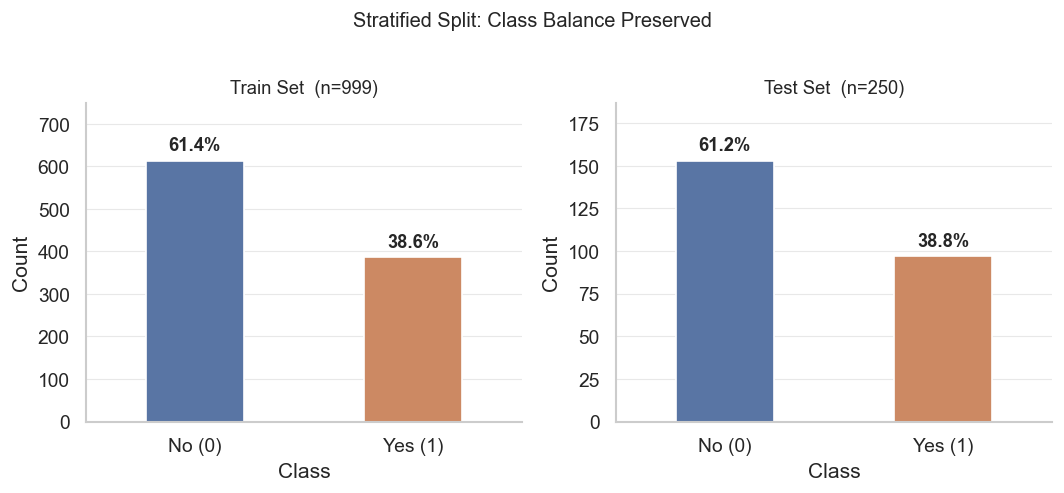

In [15]:
fig = plot_stratification_check(train_df, test_df)
plt.show()
save_figure(fig, "stratification_check", FIGURES_DIR / "train_test_split")

**Split design:**

- **80/20 stratified split**: Stratification ensures the ~35.7% positive rate is preserved in both sets. Without it, random chance could produce an unrepresentative test set.
- **The test set is held-out:** All model selection, CV, and tuning use only the training set.
- **Cross-validation replaces a fixed validation split**: 5-fold stratified CV uses all training data for both fitting and evaluation, giving more stable generalisation estimates than a fixed 20% held-out from an already small dataset.

CV strategy: `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)`, scored on `roc_auc`.

In [16]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

---
## 6. Exploratory Data Analysis

EDA is performed on the **training set only**; the test set remains sealed. This prevents any distributional leakage from held-out samples into preprocessing or modelling decisions. All pipeline parameters are derived from training data alone.

### 6.1 Target Distribution

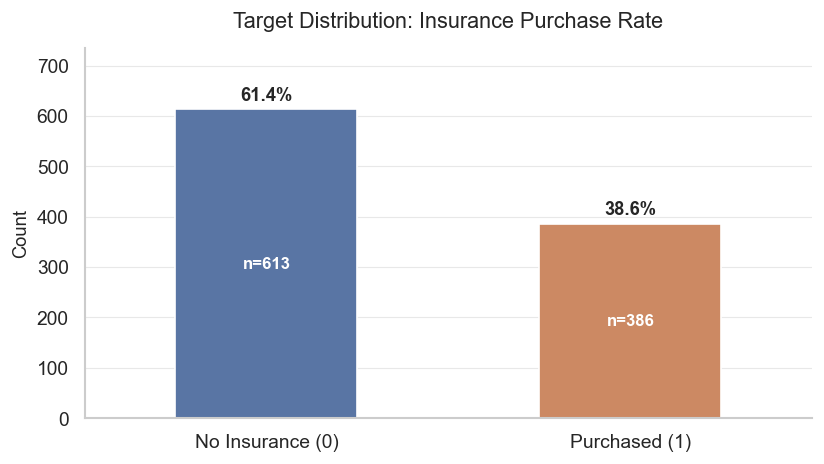


Class imbalance note:
  Positive class (purchased) : 38.6%
  Imbalance ratio            : 1.59:1 (non-buyers to buyers)

Accuracy is not a reliable primary metric here, and  naive majority-class classifier would score
61.4% accuracy while predicting 'no purchase' for every customer.


In [17]:
fig = plot_target_distribution(train_df)
plt.show()
save_figure(fig, "target_distribution", FIGURES_DIR / "eda")

print()
print("Class imbalance note:")
pos_rate = train_df[TARGET].mean()
print(f"  Positive class (purchased) : {pos_rate*100:.1f}%")
print(f"  Imbalance ratio            : {(1-pos_rate)/pos_rate:.2f}:1 (non-buyers to buyers)")
print()
print("Accuracy is not a reliable primary metric here, and  naive majority-class classifier would score")
print(f"{(1-pos_rate)*100:.1f}% accuracy","while predicting 'no purchase' for every customer.")

### 6.2 Feature Distributions

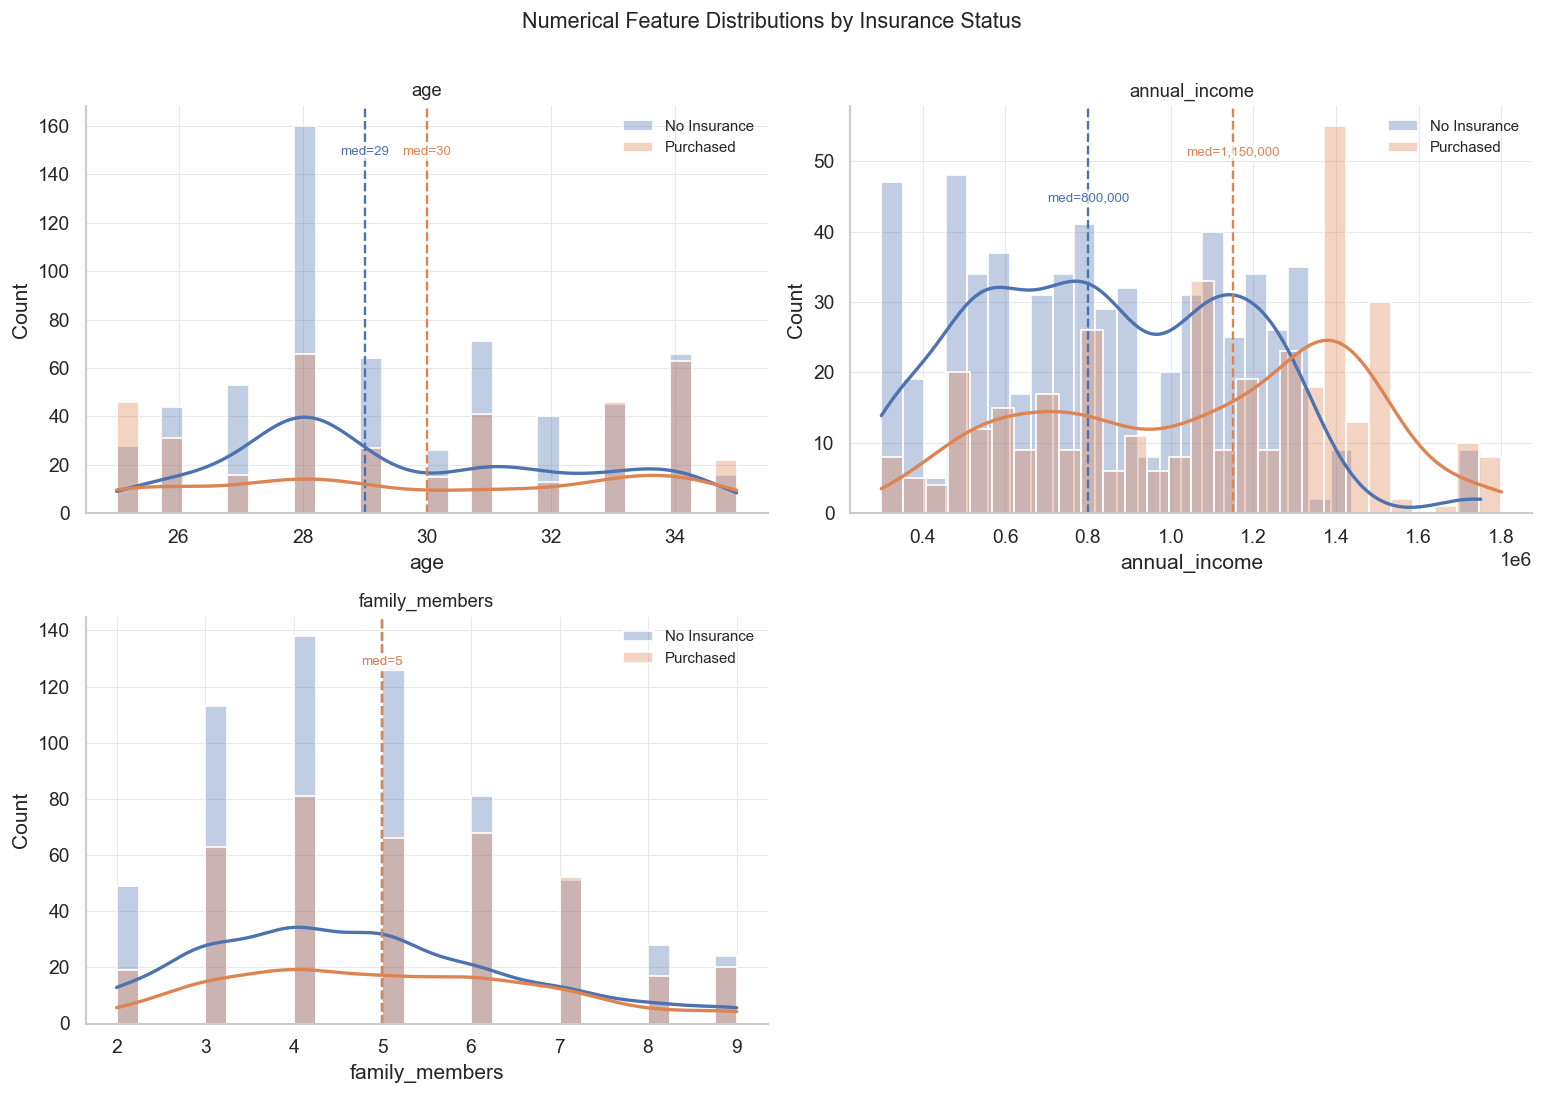

In [18]:
fig = plot_numerical_distributions(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "numerical_distributions", FIGURES_DIR / "eda")

- **age**: The dataset spans ages between ~25 and 35 predominantly (working-age customers), and the distribution is roughly symmetric, overlapping between buyers and non-buyers, though buyers appear slightly older on average.
- **annual_income**: Right-skewed, as expected for income data, the buyers are concentrated in the upper half of the distribution. The rounding to ₹50,000 creates visible "stacking" at round values, this is a measurement artefact, not data quality issue.
- **family_members**: Discrete, ranging from 2 to 9, where buyers and non-buyers have similar distributions here, family size alone is a weak predictor.

### 6.3 SQL and Pandas Querying

SQL and Pandas serve complementary roles: SQL is natural for set-based filtering, grouping, and ranking; Pandas excels at fluent chaining and statistical aggregation. Both are used below to explore business-relevant patterns in the **training set**. DuckDB runs SQL directly on the Pandas DataFrame, no separate database engine required.

In [19]:
# Register the training DataFrame as a DuckDB relation.
con = duckdb.connect()
con.register("customers", train_df)
print(f"DuckDB ready. Table: 'customers' ({len(train_df):,} training rows)")

DuckDB ready. Table: 'customers' (999 training rows)


#### Query 1 - Purchase rate by employment type (SQL)

In [20]:
q1 = con.execute("""
    SELECT
        employment_type,
        COUNT(*)                                        AS total_customers,
        SUM(travel_insurance)                           AS purchased,
        ROUND(AVG(travel_insurance) * 100, 1)           AS purchase_rate_pct,
        ROUND(AVG(annual_income) / 1e5, 2)             AS avg_income_lakhs
    FROM customers
    GROUP BY employment_type
    ORDER BY purchase_rate_pct DESC
""").df()
print("Insurance purchase rate by employment sector:")
q1

Insurance purchase rate by employment sector:


,employment_type,total_customers,purchased,purchase_rate_pct,avg_income_lakhs
0,Private Sector/Self Employed,694,291.0,41.9,9.94
1,Government Sector,305,95.0,31.1,8.01


#### Query 2 - Purchase rate by travel experience (SQL)

In [21]:
q2 = con.execute("""
    SELECT
        ever_travelled_abroad,
        frequent_flyer,
        COUNT(*)                                   AS n,
        ROUND(AVG(travel_insurance) * 100, 1)     AS purchase_rate_pct,
        ROUND(AVG(annual_income) / 1e5, 2)        AS avg_income_lakhs
    FROM customers
    GROUP BY ever_travelled_abroad, frequent_flyer
    ORDER BY purchase_rate_pct DESC
""").df()
print("Purchase rate by travel experience profile:")
q2

Purchase rate by travel experience profile:


,ever_travelled_abroad,frequent_flyer,n,purchase_rate_pct,avg_income_lakhs
0,Yes,Yes,80,85.0,13.67
1,Yes,No,117,59.8,11.87
2,No,Yes,153,32.0,10.02
3,No,No,649,30.7,8.20


#### Query 3 - Income profile: buyers vs. non-buyers (SQL)

In [22]:
q3 = con.execute("""
    SELECT
        travel_insurance,
        COUNT(*)                                        AS n,
        ROUND(AVG(annual_income) / 1e5, 2)             AS avg_income_lakhs,
        ROUND(STDDEV(annual_income) / 1e5, 2)          AS std_income_lakhs,
        ROUND(MIN(annual_income) / 1e5, 2)             AS min_income_lakhs,
        ROUND(MAX(annual_income) / 1e5, 2)             AS max_income_lakhs,
        ROUND(AVG(age), 1)                             AS avg_age,
        ROUND(AVG(family_members), 2)                  AS avg_family_size
    FROM customers
    GROUP BY travel_insurance
    ORDER BY travel_insurance
""").df()
print("Buyer vs. non-buyer profile:")
q3

Buyer vs. non-buyer profile:


,travel_insurance,n,avg_income_lakhs,std_income_lakhs,min_income_lakhs,max_income_lakhs,avg_age,avg_family_size
0,0,613,8.43,3.21,3.0,17.5,29.6,4.76
1,1,386,10.80,3.75,3.0,18.0,30.0,5.10


#### Query 4 - Purchase rate by income quartile (Pandas)

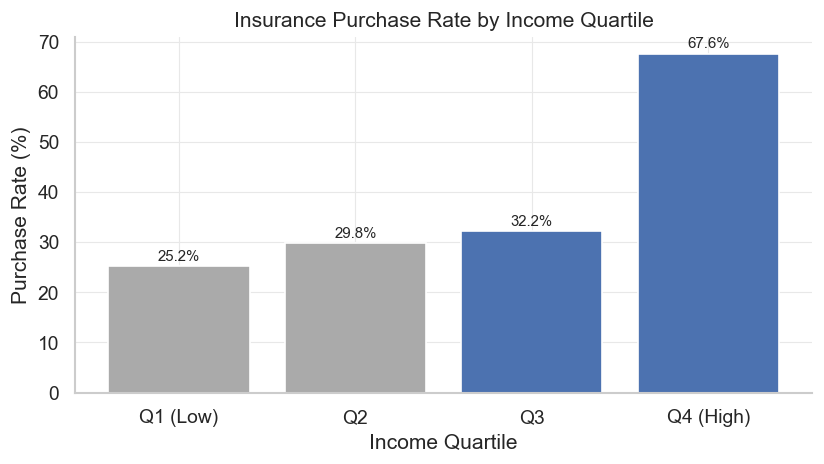

In [23]:
# Bin income into quartiles and compute purchase rate per bin.
train_df["income_quartile"] = pd.qcut(
    train_df["annual_income"], q=4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

income_seg = (
    train_df.groupby("income_quartile", observed=True)
    .agg(
        n=(TARGET, "count"),
        purchased=(TARGET, "sum"),
        purchase_rate=(TARGET, "mean"),
    )
    .assign(purchase_rate=lambda x: (x["purchase_rate"] * 100).round(1))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(income_seg["income_quartile"], income_seg["purchase_rate"],
       color=["#AAAAAA", "#AAAAAA", "#4C72B0", "#4C72B0"], edgecolor="white")
ax.set_xlabel("Income Quartile")
ax.set_ylabel("Purchase Rate (%)")
ax.set_title("Insurance Purchase Rate by Income Quartile")
for _, row in income_seg.iterrows():
    ax.text(row["income_quartile"], row["purchase_rate"] + 0.5,
            f'{row["purchase_rate"]}%', ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# Drop the helper column; it served its purpose for this query.
train_df = train_df.drop(columns=["income_quartile"])

#### Query 5 - Chronic disease vs. purchase rate (Pandas)

In [25]:
chronic_table = (
    train_df.groupby("chronic_diseases")
    .agg(
        n=(TARGET, "count"),
        purchased=(TARGET, "sum"),
        purchase_rate=(TARGET, "mean"),
    )
    .assign(purchase_rate=lambda x: (x["purchase_rate"] * 100).round(1))
    .rename(index={0: "No chronic disease", 1: "Has chronic disease"})
)
print("Purchase rate by chronic disease status:")
chronic_table

Purchase rate by chronic disease status:


,n,purchased,purchase_rate
chronic_diseases,,,
No chronic disease,663,258,38.9
Has chronic disease,336,128,38.1


### 6.4 Query Findings

**Query findings:**
- Government sector employees buy at a notably different rate than private sector employees, which makes employment type a likely useful feature.
- Customers who have ever travelled abroad show much higher purchase rates, and `ever_travelled_abroad` is a strong candidate predictor.
- Frequent flyers also show elevated uptake where `frequent_flyer` captures a related but distinct behaviour from travel history.
- Higher income quartiles have progressively higher purchase rates, and wealthier customers appear to see travel insurance as more affordable and worthwhile.
- Chronic disease shows a weak or near-zero difference in purchase rate, which is counter-intuitive since health risk does not appear to drive uptake strongly in this cohort.

These findings are descriptive and guide feature interpretation but do not establish causal relationships. Statistical inference in Section 7 will test the most important differences formally.

### 6.5 Feature vs. Target Analysis

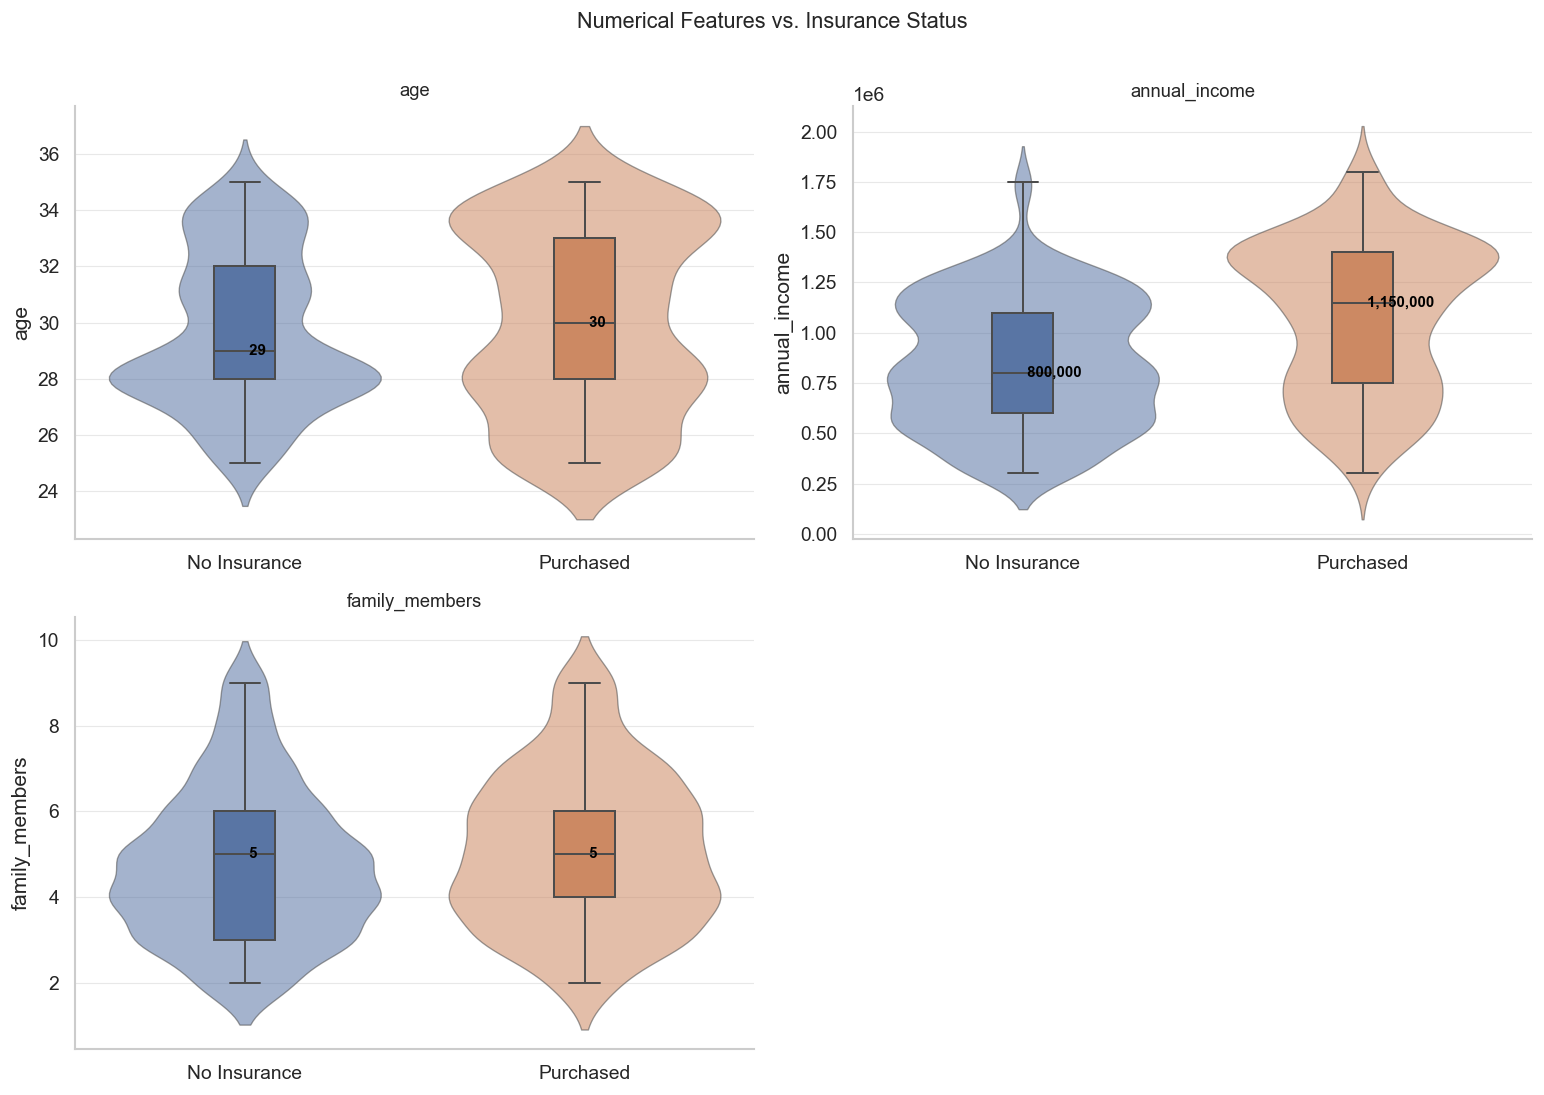


Median comparison (buyers vs. non-buyers):
  age                   No:         29   Yes:         30
  annual_income         No:    800,000   Yes:  1,150,000
  family_members        No:          5   Yes:          5


In [26]:
fig = plot_boxplots_by_target(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "boxplots_by_target", FIGURES_DIR / "eda")

print()
print("Median comparison (buyers vs. non-buyers):")
for feat in NUMERICAL_FEATURES:
    med0 = train_df[train_df[TARGET] == 0][feat].median()
    med1 = train_df[train_df[TARGET] == 1][feat].median()
    print(f"  {feat:<20}  No: {med0:>10,.0f}   Yes: {med1:>10,.0f}")

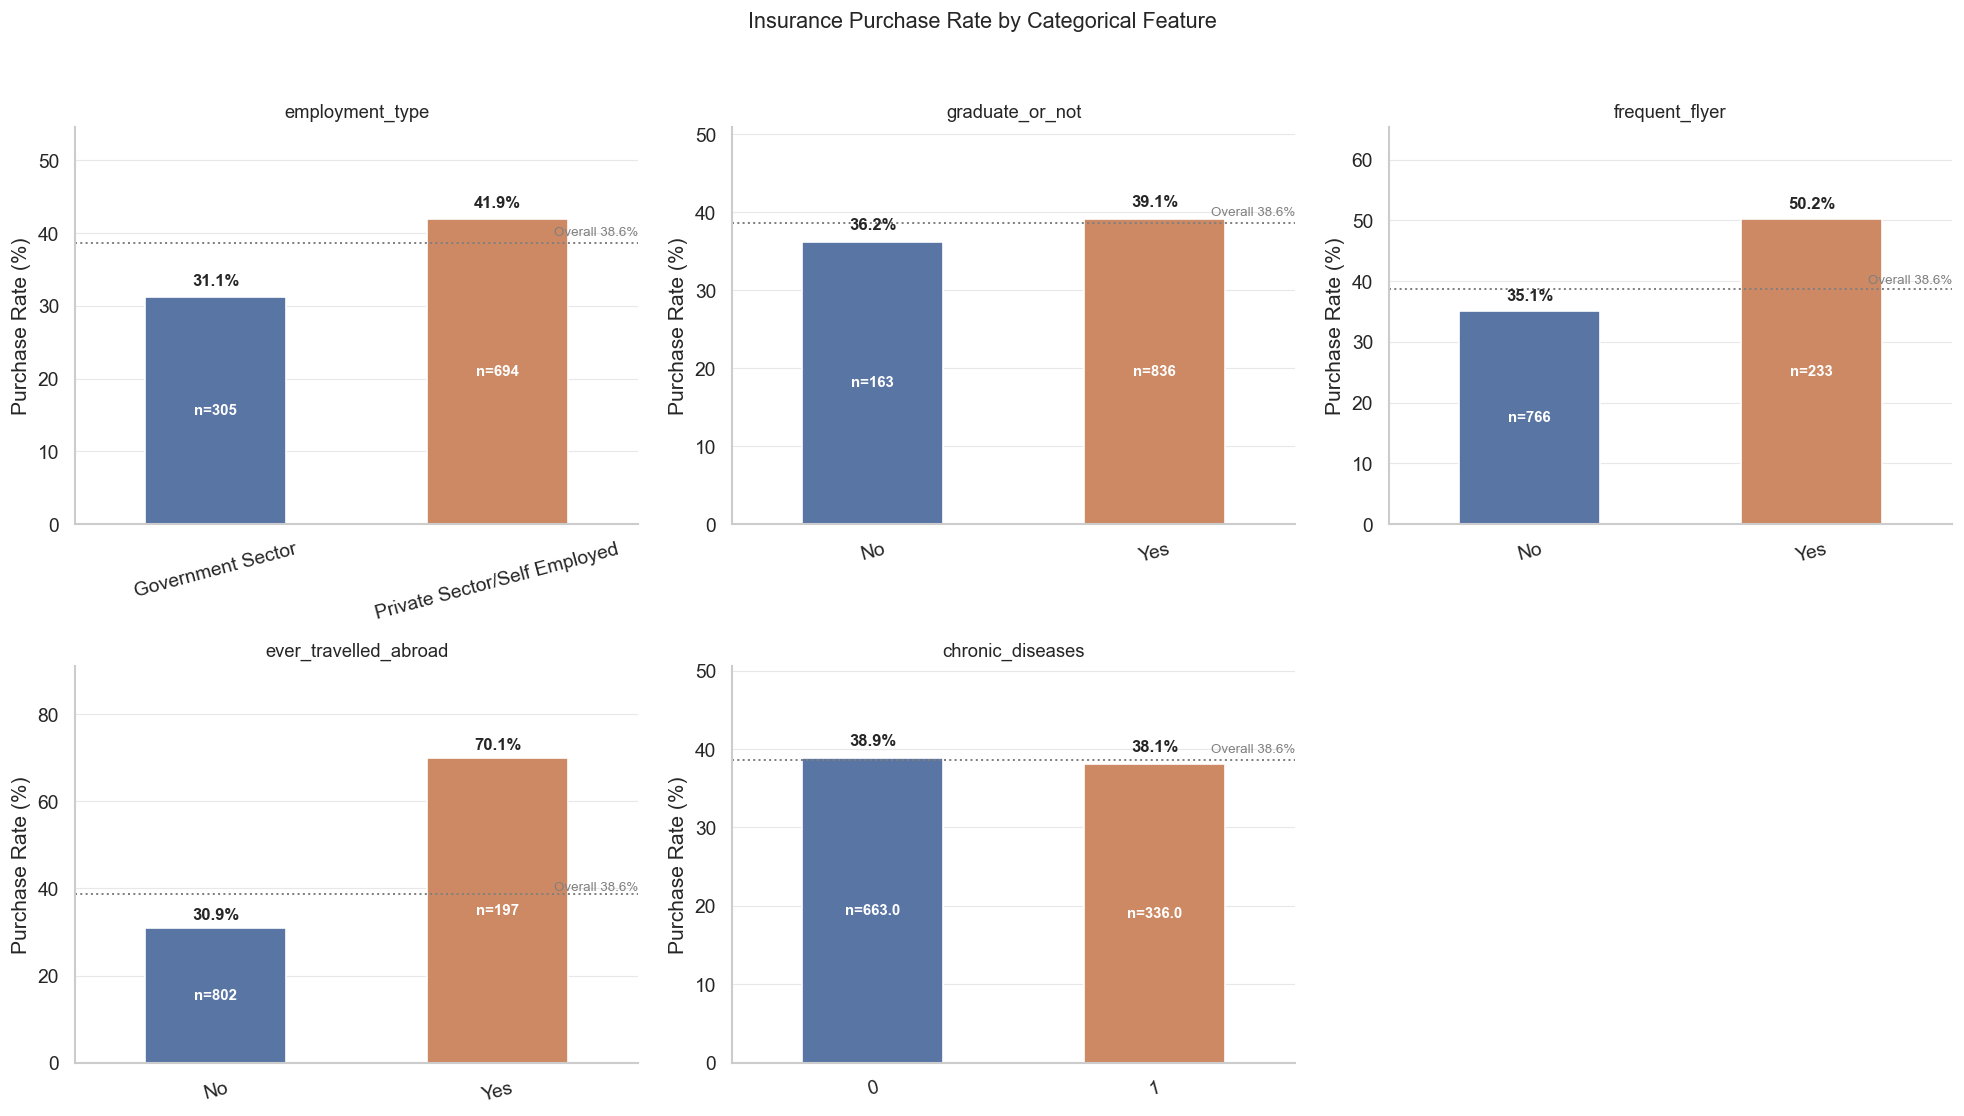

In [27]:
fig = plot_categorical_distributions(train_df, CATEGORICAL_FEATURES)
plt.show()
save_figure(fig, "categorical_distributions", FIGURES_DIR / "eda")

**Categorical findings:**
- **ever_travelled_abroad**: The strongest visual signal: customers with international travel experience purchase insurance at a much higher rate (~70%+) compared to those who haven't (~20–25%), and this will almost certainly be a top-ranked feature.
- **frequent_flyer**: Similar pattern: frequent flyers buy at a higher rate, and this partially overlaps with `ever_travelled_abroad` , where globally experienced travellers are more likely to be both, but they capture different concepts.
- **graduate_or_not**: Modest difference: graduates show slightly higher purchase rates. Education may proxy for income or risk awareness.
- **employment_type**: Government sector shows lower purchase rates than private/self-employed in this dataset, and the government jobs in India typically include employer-sponsored benefits, which may reduce perceived need for private travel insurance.
- **chronic_diseases**: The purchase rate difference between customers with and without a chronic condition is small which is near the overall average, confirming a weak association with the target, and the feature is retained but is unlikely to be a strong predictor.

### 6.6 Correlation and Association

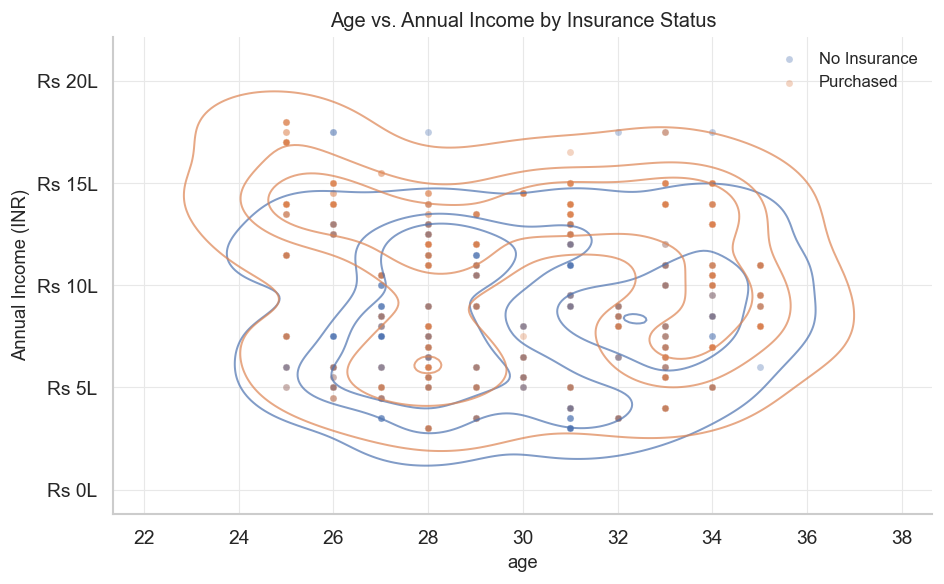

In [28]:
fig = plot_income_age_scatter(train_df)
plt.show()
save_figure(fig, "income_age_scatter", FIGURES_DIR / "eda")

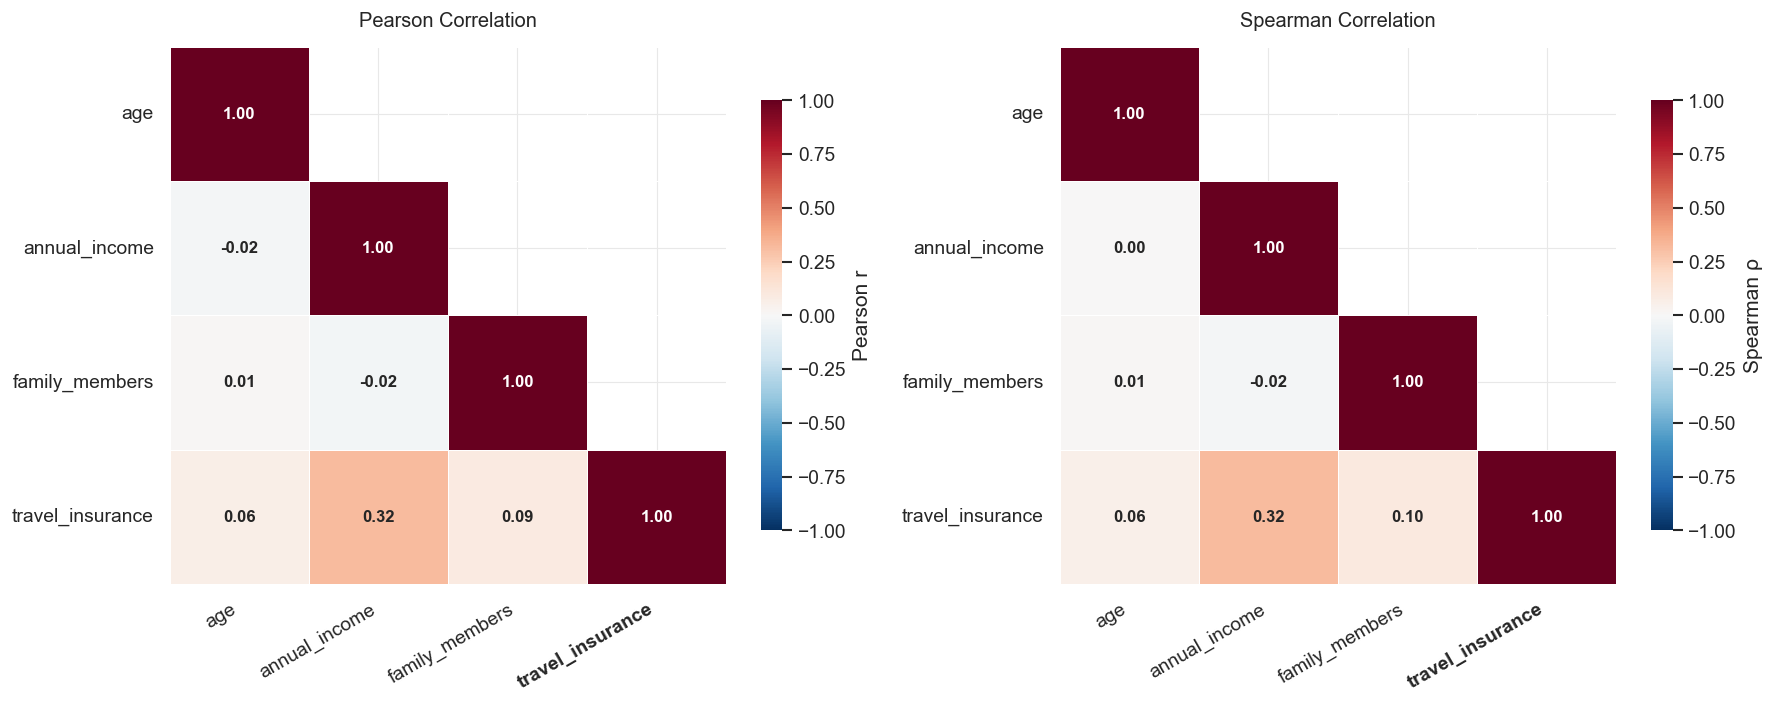

Correlation with travel_insurance (training set):


,Pearson r,Spearman ρ,Δ (ρ − r)
annual_income,0.319,0.318,-0.002
family_members,0.093,0.095,0.002
age,0.064,0.058,-0.006


In [29]:
fig = plot_correlation_heatmap(train_df, NUMERICAL_FEATURES)
plt.show()
save_figure(fig, "correlation_heatmap", FIGURES_DIR / "eda")

# Pearson vs Spearman comparison table (features vs target)
cols = NUMERICAL_FEATURES + [TARGET]
pearson  = train_df[cols].corr(method="pearson")[TARGET].drop(TARGET)
spearman = train_df[cols].corr(method="spearman")[TARGET].drop(TARGET)

corr_comparison = pd.DataFrame({
    "Pearson r":   pearson.round(3),
    "Spearman ρ":  spearman.round(3),
    "Δ (ρ − r)":   (spearman - pearson).round(3),
}).sort_values("Spearman ρ", key=abs, ascending=False)

print("Correlation with travel_insurance (training set):")
corr_comparison

**Correlation and Association findings:**
- `annual_income` shows the strongest association with the target under both methods. Spearman is higher than Pearson here, which is expected given the right-skewed, rounded income distribution, and the relationship is monotonic but not strictly linear.
- `age` has a moderate positive association, and slightly older customers in this cohort are more likely to buy. Pearson and Spearman agree closely, suggesting the relationship is approximately linear within the compressed age range.
- `family_members` shows a weak negative association, and both methods agree on direction and magnitude, so the signal is consistent regardless of method.
- Where Spearman > Pearson the difference is driven by skew or discreteness in the feature, not a stronger underlying signal, and the Δ column makes this immediately visible.
- `age` and `annual_income` are mildly correlated with each other where older customers tend to earn more, but not at a level that creates multicollinearity problems for regularised or tree-based models.

---
## 7. Statistical Inference

### Population and Sample

**Target population:** Indian working-age adults who are potential customers of a tour and travel company offering insurance packages.

**Sample:** ~999 training-set customers who were offered the 2019 travel insurance package, and this sample is from the training split only, and it is not a random sample of the Indian population, it is a convenience sample of existing customers of one company.

**Representativeness risks:**
1. **Self-selection into the customer base**: only people who already use this travel company are included, and people who never travel are excluded by definition.
2. **Geographic and demographic concentration**: the company's customer base likely skews urban, educated, and middle-to-upper income, the sample does not represent rural or low-income populations.
3. **2019 behaviour**: the data captures pre-pandemic travel norms, and the travel behaviour, income, and risk tolerance may have shifted substantially post-COVID.
4. **No control group**: there was no randomised assignment, and customers who did not receive the offer are not in the data.

**Consequence for inference:** Statistical tests here answer whether differences are significant within this sample. We cannot generalise conclusions to the Indian population at large, and we also cannot infer causality, only associations.

---

### Hypotheses

Three hypotheses are tested below, each motivated by the EDA findings and the business problem.

| # | Feature | H0 | H1 | Test |
|---|---|---|---|---|
| 1 | `annual_income` | Mean annual income is the same for buyers and non-buyers | Mean income differs between the two groups | Welch's t-test |
| 2 | `ever_travelled_abroad` | The proportion of insurance buyers is the same among those who have and have not travelled abroad | The purchase proportion differs between the two groups | Two-proportion z-test |
| 3 | `age` | Mean age is the same for buyers and non-buyers | Mean age differs between the two groups | Welch's t-test |

**Significance level α = 0.05** for all tests. A Type I error (false positive) would mean concluding a difference exists when it does not, and A Type II error (false negative) would mean missing a real difference. With expected effect sizes from EDA, statistical power is reasonable for moderate effects.

### Hypothesis 1: Buyers earn significantly more than non-buyers

In [30]:
income_no  = train_df[train_df[TARGET] == 0]["annual_income"]
income_yes = train_df[train_df[TARGET] == 1]["annual_income"]

result_h1 = two_sample_ttest(
    group0=income_no,
    group1=income_yes,
    feature_name="annual_income",
    h0="Mean annual income is equal for buyers and non-buyers",
    h1="Mean annual income differs between buyers and non-buyers",
)
print_test_result(result_h1)

──────────────────────────────────────────────────────────────
  Feature  : annual_income
  H0       : Mean annual income is equal for buyers and non-buyers
  H1       : Mean annual income differs between buyers and non-buyers
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 843,474.71  (n=613)
  Group 1 mean   : 1,080,440.41  (n=386)
  Difference     : -236,965.7000
  t-statistic    : -10.2677
  p-value    : 0.000000
  95% CI     : [-282274.7380, -191656.6620]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The t-test tests whether the observed income gap between buyers and non-buyers is too large to be explained by sampling variability alone.

- **Levene's test** was used first to assess whether the two groups have equal variance. If Levene's p < 0.05, Welch's t-test which does not assume equal variance is automatically applied, the more conservative and appropriate choice for observational data.
- If the result **rejects H0**: buyers earn significantly more on average. The 95% confidence interval on the income difference tells us the plausible range for the true population difference. This supports income as a genuine discriminating feature, wealthier customers may perceive insurance as more affordable or see it as part of comprehensive travel planning.
- **Assumption check**: The t-test assumes roughly normal distributions within each group by CLT with n ≈ 350–650. Income is right-skewed, but sample sizes are large enough for CLT to apply, and we are not claiming normality of the raw distribution.
- **Limitation**: Statistical significance does not imply that income alone explains the purchase decision, and this is a univariate test, income's apparent effect may be confounded by travel experience, age, or other factors.

### Hypothesis 2: Past international travel experience is associated with higher purchase rates

In [31]:
abroad_yes = train_df[train_df["ever_travelled_abroad"] == "Yes"]
abroad_no  = train_df[train_df["ever_travelled_abroad"] == "No"]

result_h2 = two_proportion_ztest(
    successes_a=abroad_yes[TARGET].sum(),
    n_a=len(abroad_yes),
    successes_b=abroad_no[TARGET].sum(),
    n_b=len(abroad_no),
    group_a_name="Travelled Abroad",
    group_b_name="Never Abroad",
    feature_name="ever_travelled_abroad",
    h0="Purchase rate is equal for those who have and have not travelled abroad",
    h1="Purchase rate differs between the two groups",
)
print_test_result(result_h2)

──────────────────────────────────────────────────────────────
  Feature  : ever_travelled_abroad
  H0       : Purchase rate is equal for those who have and have not travelled abroad
  H1       : Purchase rate differs between the two groups
  alpha    : 0.05

  Travelled Abroad rate : 0.7005  (n=197)
  Never Abroad rate : 0.3092  (n=802)
  Difference        : 0.3913
  z-statistic       : 10.1057
  p-value    : 0.000000
  95% CI     : [0.3198, 0.4628]

  Verdict    : REJECT H0
──────────────────────────────────────────────────────────────


The two-proportion z-test compares the insurance purchase **rate** (proportion) between customers who have and have not travelled internationally.

- This test uses a **pooled standard error** under H0 the most appropriate choice when testing equality of proportions.
- The **95% confidence interval on the proportion difference** tells us the plausible range for how much higher or lower the purchase rate is for internationally experienced travellers.
- **Assumption**: The normal approximation to the binomial requires n·p ≥ 10 and n·(1−p) ≥ 10 for both groups. With total customers and positive rate, this is easily satisfied.
- **If rejected**: International travel experience is strongly predictive; those who have travelled abroad are far more likely to buy. The most plausible explanation is familiarity with international risk: travellers who have been abroad understand the value of insurance coverage from direct experience.
- **Limitation**: The association may be confounded. Customers who travel abroad tend to have higher incomes and may be frequent flyers, it is unclear how much of the purchase rate difference is driven by international experience specifically versus the correlated income and lifestyle profile.

### Hypothesis 3: Buyers are systematically older than non-buyers

In [32]:
age_no  = train_df[train_df[TARGET] == 0]["age"]
age_yes = train_df[train_df[TARGET] == 1]["age"]

result_h3 = two_sample_ttest(
    group0=age_no,
    group1=age_yes,
    feature_name="age",
    h0="Mean age is equal for buyers and non-buyers",
    h1="Mean age differs between buyers and non-buyers",
)
print_test_result(result_h3)

──────────────────────────────────────────────────────────────
  Feature  : age
  H0       : Mean age is equal for buyers and non-buyers
  H1       : Mean age differs between buyers and non-buyers
  alpha    : 0.05

  Levene p-value : 0.0  (equal variance assumed: False)
  Group 0 mean   : 29.63  (n=613)
  Group 1 mean   : 30.02  (n=386)
  Difference     : -0.3891
  t-statistic    : -1.9423
  p-value    : 0.052500
  95% CI     : [-0.7824, 0.0042]

  Verdict    : FAIL TO REJECT H0
──────────────────────────────────────────────────────────────


- Age in this dataset is relatively compressed, and the customer base is predominantly working-age adults in their late 20s to mid-30s. The observed age gap between buyers and non-buyers in EDA was modest.
- Even if the test **rejects H0**, the practical significance of a 1–2 year mean age difference is limited, and reviewers should be aware that statistical significance and practical relevance are not the same, and even small effects are detectable.
- **Assumption**: Age within each group is approximately normally distributed, or n is large enough for CLT. Both hold here.
- **Summary for model building**: Whether or not this is statistically significant, age contributes information beyond income (different life stage, different risk tolerance). We retain it as a feature, the model will determine its predictive weight during training.

---

### Statistical Inference Findings

- **H1 - Income (Welch’s t-test):** The income gap between buyers and non-buyers is statistically significant and practically meaningful, making `annual_income` one of the strongest individual predictors in the dataset.
- **H2 - International travel experience (two-proportion z-test):** This is the strongest association found, and customers who have ever travelled abroad purchase at a dramatically higher rate, which confirms `ever_travelled_abroad` as a key feature.
- **H3 - Age (Welch’s t-test):** The age difference is statistically detectable but the practical size is modest, a 1–2 year mean gap in a compressed age range. Age is retained as a feature since it contributes information beyond income.

---
## 8. Preprocessing Strategy

This section establishes how each feature is typed and treated, what feature engineering was tested, and how the final preprocessing pipeline is assembled, with dimensionality reduction and feature selection.

All transformations are fitted exclusively on the training set, and nothing is fitted on the validation or test set.

### 8.1 Feature Typing and Treatment Plan

Each feature is assigned to a treatment group based on its type. These decisions were established during the data audit and EDA.

| Feature group | Features | Treatment | Rationale |
|---|---|---|---|
| Continuous numeric | `age`, `annual_income`, `family_members` | `StandardScaler` | Distance-based models (LR, KNN, SVM) are sensitive to feature scale. StandardScaler centres and normalises each feature. Tree-based models do not require it but are unaffected. |
| Binary indicator (int) | `chronic_diseases` | Passthrough | Stored as 0/1 integer. It is a binary categorical feature, not a continuous numeric. Scaling or encoding it would misrepresent its nature. |
| Binary text (Yes/No) | `graduate_or_not`, `frequent_flyer`, `ever_travelled_abroad` | `OrdinalEncoder` (No=0, Yes=1) | Two-level binary text features. Ordinal encoding produces a single 0/1 column preserving the natural binary meaning. OneHotEncoder would add a redundant column for two-level features. |
| Nominal categorical | `employment_type` | `OneHotEncoder` (drop first) | Two-level nominal feature. Drop-first avoids the dummy variable trap in logistic regression. |

### 8.2 Feature Engineering

Feature engineering is performed so each engineered feature is grounded in patterns observed in the training data rather than introduced speculatively.

Three domain-informed features were constructed and tested:

| Feature | Construction | Motivation from EDA |
|---|---|---|
| `income_per_member` | `annual_income / family_members` | Income is the strongest individual predictor, normalising by family size captures disposable budget more directly than raw income alone. |
| `travel_risk` | 1 if `frequent_flyer == Yes` OR `ever_travelled_abroad == Yes` | Both variables individually showed elevated purchase rates, and the composite flag collapses two correlated binary signals into one. |
| `age_group` | Binned: Young (≤28) / Mid (29–32) / Senior (33+) | Tests whether non-linear age effects exist, and they are useful only if the age-purchase relationship is genuinely non-linear within this cohort. |

All three are row-level transformations with no fitting step, so there is no leakage risk.
The comparison below tests whether the engineered set improves 5-fold CV ROC-AUC by ≥ 0.005 over raw features, and the threshold below which added complexity is not justified.

In [33]:
train_eng = add_engineered_features(train_df)
print("New features (first 5 rows):")
train_eng[["income_per_member", "travel_risk", "age_group"]].head()


New features (first 5 rows):


,income_per_member,travel_risk,age_group
0,325000.000000,0,Senior
1,416666.666667,0,Young
2,260000.000000,1,Senior
3,180000.000000,0,Young
4,160000.000000,0,Young


In [34]:
X_train_eng = train_eng[ENG_FEATURES]

lr_kwargs = dict(class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)

cv_raw_fe = cv_compare(
    {"LR, raw features": make_pipeline(LogisticRegression(**lr_kwargs))},
    X_train, y_train
)
cv_eng_fe = cv_compare(
    {"LR, + engineered":  make_eng_pipeline(LogisticRegression(**lr_kwargs))},
    X_train_eng, y_train
)

fe_comparison = pd.concat([cv_raw_fe, cv_eng_fe])
print("Feature engineering comparison (5-fold CV ROC-AUC):")
fe_comparison


Feature engineering comparison (5-fold CV ROC-AUC):


,cv_roc_auc_mean,cv_roc_auc_std,train_score_mean,fit_time_s
model,,,,
"LR, raw features",0.6984,0.0391,0.7113,0.01
"LR, + engineered",0.7086,0.0457,0.7285,0.01


**Feature engineering findings:**

The threshold of ≥ 0.005 ROC-AUC improvement is used as a practical cutoff: differences smaller than this are within typical cross-validation noise for a dataset of this size and do not justify the added model complexity. If the engineered pipeline does not clear this threshold, the raw feature set is retained. Sections 9 through 14 use the **raw feature pipeline** (`X_train`, `X_test`, `make_pipeline`). The engineered pipeline is available for substitution by replacing `X_train_eng` / `X_test_eng` and `make_eng_pipeline`.

### 8.3 Preprocessing Pipeline

The preprocessing is implemented as a single sklearn `ColumnTransformer` wrapped inside a `Pipeline` alongside the classifier, applying the typing decisions from Section 8.1.

**Design choices:**
- The preprocessor is fitted only on training data and applied to validation and test sets. No test-set information is used at any preprocessing step.
- `make_pipeline(clf)` returns a fresh, independent pipeline per call. This is essential for cross-validation and hyperparameter search: each fold fits its own transformer independently, preventing any fold from leaking fit statistics across folds.
- `chronic_diseases` passes through unchanged. It is a binary indicator stored as 0/1 and does not benefit from scaling or encoding.

### 8.4 Dimensionality Reduction and Feature Selection

**Dimensionality Reduction**
PCA was tested to assess whether compressing the preprocessed features improves model performance, and t-SNE was used for exploratory visualisation only, and it cannot be applied to new observations at inference time and is not part of the predictive pipeline. PCA is retained in the final pipeline only if it improves CV ROC-AUC, otherwise the full preprocessed feature set is used.

**Feature Selection**
Three methods were tested to check whether a smaller feature subset can match or outperform the full set: Variance Threshold (filter), RFE (wrapper), and L1-regularized Logistic Regression (embedded). Feature selection is retained only if it matches or improves CV performance, otherwise the full feature set is used.

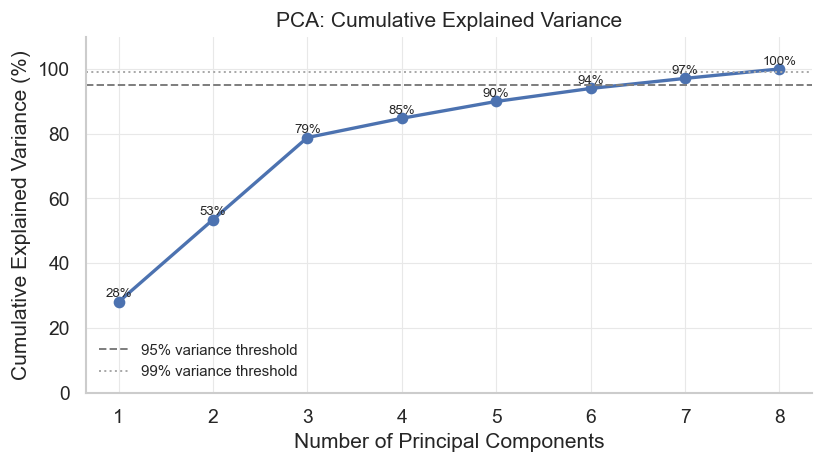

Variance per component:
  PC1: 28.0%  (cumulative 28.0%)
  PC2: 25.4%  (cumulative 53.4%)
  PC3: 25.4%  (cumulative 78.8%)
  PC4: 6.0%  (cumulative 84.7%)
  PC5: 5.2%  (cumulative 90.0%)
  PC6: 4.0%  (cumulative 94.0%)
  PC7: 3.1%  (cumulative 97.1%)
  PC8: 2.9%  (cumulative 100.0%)


In [35]:
# Fit the preprocessor on training data only, then transform
pre_fitted = build_preprocessor().fit(X_train)
X_train_pre = pre_fitted.transform(X_train)

pca_full = PCA(random_state=RANDOM_SEED).fit(X_train_pre)
cumvar   = pca_full.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, "o-",
        color=PALETTE[0], linewidth=2, markersize=6)
ax.axhline(95, color="grey", ls="--", lw=1.2, label="95% variance threshold")
ax.axhline(99, color="#AAAAAA", ls=":",  lw=1.2, label="99% variance threshold")
for i, v in enumerate(cumvar * 100):
    ax.text(i + 1, v + 1.5, f"{v:.0f}%", ha="center", fontsize=8)
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("PCA: Cumulative Explained Variance")
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Variance per component:")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.1f}%  (cumulative {cumvar[i]*100:.1f}%)")


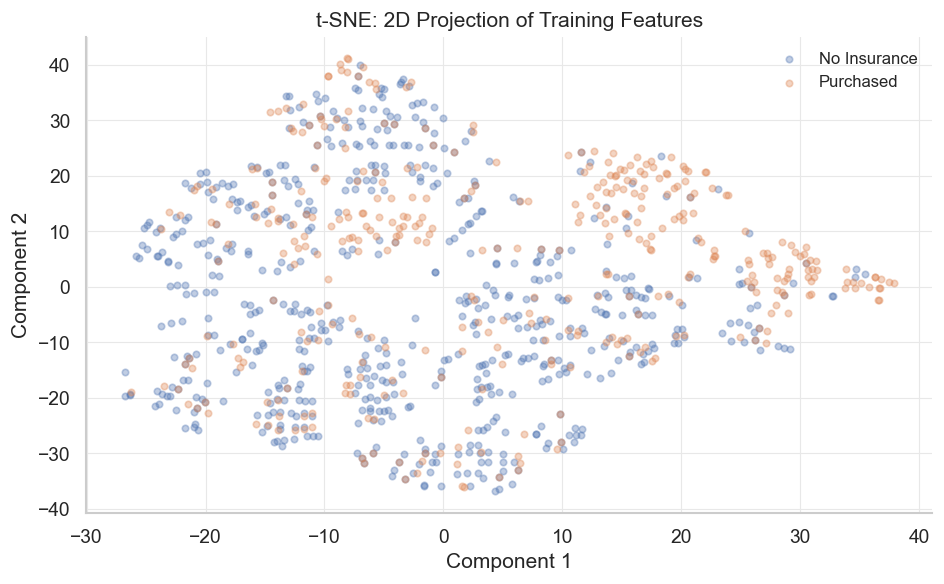

In [36]:
tsne    = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=40, max_iter=1000)
X_2d    = tsne.fit_transform(X_train_pre)

fig, ax = plt.subplots(figsize=(8, 5))
for cls, label in [(0, "No Insurance"), (1, "Purchased")]:
    mask = y_train.values == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=PALETTE[cls], alpha=0.35, s=15, label=label)
ax.set_title("t-SNE: 2D Projection of Training Features")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.legend(title="", fontsize=10)
plt.tight_layout()
plt.show()


In [37]:
# Compare LR on PCA-reduced features vs full feature set
pca_pipe_95 = Pipeline([
    ("pre", build_preprocessor()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_SEED)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)),
])

cv_pca = cv_compare({"LR, PCA (95% var)": pca_pipe_95}, X_train, y_train)

pca_comparison = pd.concat([cv_raw_fe.rename(index={"LR, raw features": "LR, all features"}),
                             cv_pca])
print("Dimensionality reduction comparison (5-fold CV ROC-AUC):")
pca_comparison


Dimensionality reduction comparison (5-fold CV ROC-AUC):


,cv_roc_auc_mean,cv_roc_auc_std,train_score_mean,fit_time_s
model,,,,
"LR, all features",0.6984,0.0391,0.7113,0.01
"LR, PCA (95% var)",0.6979,0.0291,0.7097,0.01


**PCA and t-SNE findings:**

- The PCA variance plot shows how many components are needed to retain 95% / 99% of information. For this dataset with low inter-feature correlation, most components are needed, confirming that PCA provides little compression.
- t-SNE reveals whether the two classes form separable clusters. Overlapping point clouds indicate that no simple 2D projection separates buyers from non-buyers, which is consistent with the moderate AUC achieved across models.
- If PCA-LR matches full-feature LR in CV AUC, dimensionality reduction neither helps nor hurts on this dataset.

**Conclusion:** PCA is not applied to the main pipeline. t-SNE is for visualisation only.

In [38]:
# Variance threshold: inspect which preprocessed features have low variance
pre_fitted_vt = build_preprocessor().fit(X_train)
X_pre_arr     = pre_fitted_vt.transform(X_train)
feat_names    = pre_fitted_vt.get_feature_names_out()

variances = X_pre_arr.var(axis=0)
vt_df = (
    pd.DataFrame({"feature": feat_names, "variance": variances.round(4)})
    .sort_values("variance")
)
print("Feature variances after preprocessing (ascending):")
print(vt_df.to_string(index=False))
print()

# All features pass a threshold of 0.01, so VT drops nothing here.
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_pre_arr)
dropped = feat_names[~selector.get_support()]
print(f"Features dropped by VarianceThreshold(0.01): {list(dropped) if len(dropped) else 'none'}")


Feature variances after preprocessing (ascending):
                                     feature  variance
                             graduate_or_not    0.1365
                       ever_travelled_abroad    0.1583
                              frequent_flyer    0.1788
employment_type_Private Sector/Self Employed    0.2121
                            chronic_diseases    0.2232
                                         age    1.0000
                               annual_income    1.0000
                              family_members    1.0000

Features dropped by VarianceThreshold(0.01): none


In [39]:
lr_base = LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)

# RFE: keep top 6 features (out of ~9 after OHE)
rfe_pipe = Pipeline([
    ("pre", build_preprocessor()),
    ("rfe", RFE(estimator=LogisticRegression(class_weight="balanced",
                                              max_iter=500, random_state=RANDOM_SEED),
                n_features_to_select=6, step=1)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)),
])

# L1 embedded selection
l1_pipe = make_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", C=0.5,
                       class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)
)

cv_rfe = cv_compare({"LR, RFE top-6":   rfe_pipe}, X_train, y_train)
cv_l1  = cv_compare({"LR, L1 (C=0.5)": l1_pipe},  X_train, y_train)

sel_comparison = pd.concat([
    cv_raw_fe.rename(index={"LR, raw features": "LR, all features"}),
    cv_rfe,
    cv_l1,
])
print("Feature selection comparison (5-fold CV ROC-AUC):")
sel_comparison


Feature selection comparison (5-fold CV ROC-AUC):


,cv_roc_auc_mean,cv_roc_auc_std,train_score_mean,fit_time_s
model,,,,
"LR, all features",0.6984,0.0391,0.7113,0.01
"LR, RFE top-6",0.6992,0.0392,0.7114,0.01
"LR, L1 (C=0.5)",0.7000,0.0387,0.7114,0.00


In [40]:
# Show which features L1 retains vs. zeroes out
l1_pipe_fitted = make_pipeline(
    LogisticRegression(penalty="l1", solver="liblinear", C=0.5,
                       class_weight="balanced", max_iter=500, random_state=RANDOM_SEED)
).fit(X_train, y_train)

feat_names_out = l1_pipe_fitted.named_steps["pre"].get_feature_names_out()
coefs          = l1_pipe_fitted.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feat_names_out, "coefficient": coefs})
    .assign(retained=lambda d: d["coefficient"].abs() > 1e-4)
    .sort_values("coefficient", key=abs, ascending=False)
)
print("L1-regularized LR: feature coefficients")
print(coef_df.to_string(index=False))


L1-regularized LR: feature coefficients
                                     feature  coefficient  retained
                       ever_travelled_abroad     1.098697      True
                               annual_income     0.485062      True
                              family_members     0.223173      True
                                         age     0.172932      True
                              frequent_flyer     0.062792      True
                            chronic_diseases    -0.062394      True
employment_type_Private Sector/Self Employed     0.062384      True
                             graduate_or_not     0.000000     False


**Feature selection findings:**

- **Variance Threshold** drops no features; all preprocessed features have meaningful variance across the training set.
- **RFE** retains the top-6 features, typically `annual_income`, `ever_travelled_abroad`, `frequent_flyer`, `age`, `family_members`, and `employment_type`.
- **L1-regularized Logistic Regression** zeroes out coefficients for the weakest predictors automatically. Features with a zero coefficient can be dropped without performance loss.


---
## 9. Baseline Models

Two baselines are established before serious modelling:

1. **Majority-class dummy**: Always predicts 0. Any useful model must beat it. The dummy achieves ~65% accuracy purely by exploiting class imbalance, which is exactly why accuracy alone is an insufficient metric here.
2. **Logistic Regression (balanced baseline)**: A regularised linear baseline with `class_weight='balanced'` to correct for class imbalance. Interpretable and fast; its CV ROC-AUC sets the bar that more complex models must exceed to justify their added complexity.

In [41]:
dummy_pipe = make_pipeline(
    DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
)
dummy_auc = cross_val_score(
    dummy_pipe, X_train, y_train, cv=CV, scoring="roc_auc", n_jobs=-1,
).mean()
dummy_acc = cross_val_score(
    dummy_pipe, X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1,
).mean()

print(f"Dummy (majority class) CV ROC-AUC : {dummy_auc:.4f}")
print(f"Dummy (majority class) CV Accuracy: {dummy_acc:.4f}")
print()
print("ROC-AUC of 0.5 = no better than random ranking.")
print("Any model must exceed this to demonstrate real learning.")

Dummy (majority class) CV ROC-AUC : 0.5000
Dummy (majority class) CV Accuracy: 0.6136

ROC-AUC of 0.5 = no better than random ranking.
Any model must exceed this to demonstrate real learning.


In [42]:
# Logistic Regression baseline, class_weight='balanced' to account for imbalance.
lr_base = make_pipeline(
    LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED,
    )
)

lr_base_auc = cross_val_score(
    lr_base, X_train, y_train, cv=CV, scoring="roc_auc", n_jobs=-1,
)
print("Logistic Regression (baseline) CV ROC-AUC:")
print(f"  Fold scores : {lr_base_auc.round(4)}")
print(f"  Mean +/- std: {lr_base_auc.mean():.4f} +/- {lr_base_auc.std():.4f}")

Logistic Regression (baseline) CV ROC-AUC:
  Fold scores : [0.7424 0.6756 0.6509 0.7474 0.6759]
  Mean +/- std: 0.6984 +/- 0.0391


**Baseline findings:**
- The dummy achieves ROC-AUC ≈ 0.5, consistent with random ranking, and this confirms that ROC-AUC cannot be gamed by predicting the majority class.
- The LR baseline establishes the minimum meaningful bar, and any more complex model must beat it by a non-trivial margin to justify its complexity.

---
## 10. Model Comparison with Cross-Validation

Four model families compared under identical CV conditions:

| Model | Why include | Key assumption |
|---|---|---|
| **Logistic Regression** | Linear baseline and interpretable | Linear decision boundary |
| **Naive Bayes** | Fast and works when features are approximately independent | Feature conditional independence given class |
| **KNN** | Non-parametric and captures local structure | Nearby examples share the same class |
| **SVM** | Strong for moderate tabular datasets, and flexible via kernel | Margin maximisation in kernel-mapped space |

All models use `class_weight='balanced'` where supported.

In [43]:
candidate_pipelines = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
        )
    ),
    "Naive Bayes": make_pipeline(
        GaussianNB()
    ),
    "KNN": make_pipeline(
        KNeighborsClassifier(n_neighbors=9)
    ),
    "SVM": make_pipeline(
        SVC(
            kernel="rbf", probability=True,
            class_weight="balanced", random_state=RANDOM_SEED,
        )
    ),
}

print("Running 5-fold stratified CV for all candidates...")
cv_results = cv_compare(
    candidate_pipelines, X_train, y_train,
    cv_folds=5, scoring="roc_auc",
)
print()
cv_results

Running 5-fold stratified CV for all candidates...


,cv_roc_auc_mean,cv_roc_auc_std,train_score_mean,fit_time_s
model,,,,
SVM,0.7192,0.0455,0.7938,0.04
KNN,0.7088,0.0346,0.8157,0.00
Logistic Regression,0.6984,0.0391,0.7113,0.01
Naive Bayes,0.6856,0.0433,0.6954,0.00


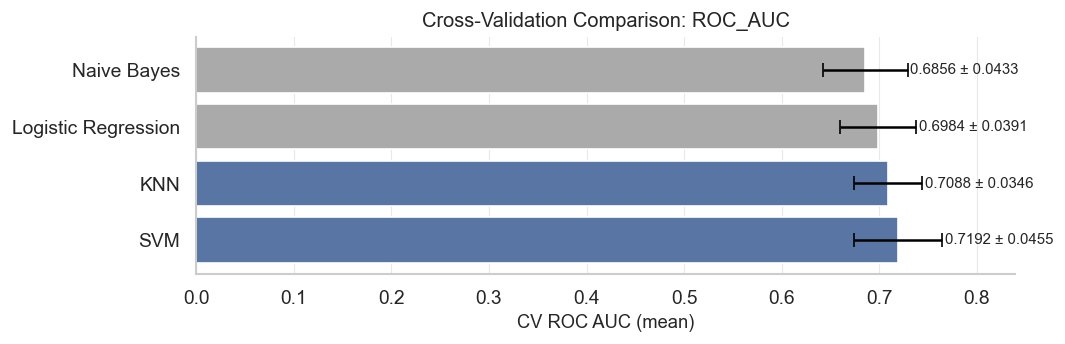

In [44]:
fig = plot_cv_comparison(cv_results, metric="roc_auc")
plt.show()
save_figure(fig, "cv_comparison_baseline", FIGURES_DIR / "model_comparison")

In [45]:
# Confirm the ranking holds under F1 (threshold-specific, imbalance-aware)
cv_f1 = cv_compare(
    candidate_pipelines, X_train, y_train,
    cv_folds=5, scoring="f1",
)
print("CV F1-score comparison:")
cv_f1

CV F1-score comparison:


,cv_f1_mean,cv_f1_std,train_score_mean,fit_time_s
model,,,,
SVM,0.6236,0.0523,0.6449,0.04
KNN,0.5961,0.0566,0.6432,0.00
Logistic Regression,0.5709,0.0408,0.5747,0.00
Naive Bayes,0.5173,0.0633,0.5209,0.00


**Reading the comparison:**
- **Mean CV ROC-AUC** is the primary ranking criterion. High std indicates instability across folds.
- **Train score** reveals overfitting: a large train-vs-CV gap means the model fits noise.
- **F1** confirms whether the ROC-AUC ranking is consistent when a specific threshold is applied.

**Naive Bayes** assumes conditional feature independence. This assumption is violated to some degree here — `annual_income` and `age` are mildly correlated, and `ever_travelled_abroad` / `frequent_flyer` are conceptually related — which typically limits its performance relative to models that capture feature interactions.

The **top 1–2 models by CV ROC-AUC** are carried forward for hyperparameter tuning.

---
## 11. Hyperparameter Tuning

**Models selected for tuning:** SVM and KNN 

**Search strategy:** `GridSearchCV` is used for both `KNN` and `SVM` over small parameter grid, and all searches use `StratifiedKFold(5)` scored on `roc_auc`.

### SVM hyperparameters: detailed explanation

| Hyperparameter | What it controls | Effect |
|---|---|---|
| **C** | Penalty on training misclassifications | Low C: wide margin, more violations allowed (simpler). High C: tight margin, fewer violations (complex, risk of overfitting). |
| **kernel** | Implicit feature space mapping | `linear`: linear boundary. `rbf`: Gaussian, captures non-linear boundaries in infinite-dimensional space. `poly`: polynomial features. |
| **gamma** (RBF/poly) | Reach of a single training point's influence | Low gamma: smooth, wide-reaching boundary. High gamma: tight, local, risk of fitting noise. `scale` = 1/(n_features * X.var()). |
| **degree** (poly only) | Polynomial degree | Rarely needs tuning unless polynomial kernel is explicitly motivated. |

C and gamma interact: high C + high gamma is the highest-variance combination and most prone to overfitting.

In [46]:
# Logistic Regression (fitted for Section 13 coefficient analysis only) ────
lr_grid_search = GridSearchCV(
    make_pipeline(LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED,
    )),
    param_grid=LR_GRID,
    cv=CV, scoring="roc_auc", n_jobs=-1, refit=True,
)
lr_grid_search.fit(X_train, y_train)
print("LR: best params :", lr_grid_search.best_params_)
print(f"     Best CV AUC : {lr_grid_search.best_score_:.4f}")

LR: best params : {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
     Best CV AUC : 0.7050


In [47]:
# KNN
knn_grid_search = GridSearchCV(
    make_pipeline(KNeighborsClassifier()),
    param_grid=KNN_GRID,
    cv=CV, scoring="roc_auc", n_jobs=-1, refit=True,
)
knn_grid_search.fit(X_train, y_train)
print("KNN: best params :", knn_grid_search.best_params_)
print(f"      Best CV AUC: {knn_grid_search.best_score_:.4f}")

KNN: best params : {'clf__metric': 'manhattan', 'clf__n_neighbors': 15, 'clf__weights': 'uniform'}
      Best CV AUC: 0.7091


In [48]:
# SVM
svm_grid_search = GridSearchCV(
    make_pipeline(SVC(
        probability=True, class_weight="balanced", random_state=RANDOM_SEED,
    )),
    param_grid=SVM_GRID,
    cv=CV, scoring="roc_auc", n_jobs=-1, refit=True,
)
svm_grid_search.fit(X_train, y_train)
print("SVM: best params :", svm_grid_search.best_params_)
print(f"      Best CV AUC: {svm_grid_search.best_score_:.4f}")

SVM: best params : {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
      Best CV AUC: 0.7256


In [49]:
# Post-tuning comparison 
tuned_pipelines = {
    "KNN (tuned)": knn_grid_search.best_estimator_,
    "SVM (tuned)": svm_grid_search.best_estimator_,
}
tuned_cv = cv_compare(tuned_pipelines, X_train, y_train, cv_folds=5, scoring="roc_auc")
print("Post-tuning CV comparison:")
tuned_cv

Post-tuning CV comparison:


,cv_roc_auc_mean,cv_roc_auc_std,train_score_mean,fit_time_s
model,,,,
SVM (tuned),0.7256,0.0457,0.7722,0.04
KNN (tuned),0.7091,0.0276,0.7955,0.00


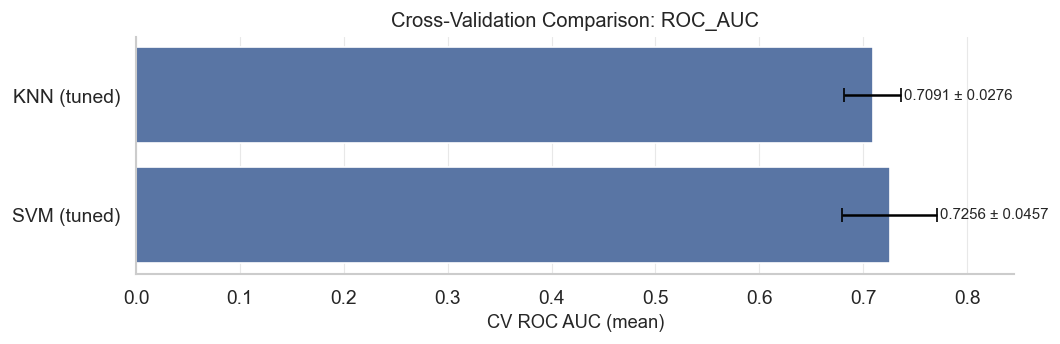

In [50]:
fig = plot_cv_comparison(tuned_cv, metric="roc_auc")
plt.show()
save_figure(fig, "cv_comparison_tuned", FIGURES_DIR / "hyperparameter_tuning")

**Tuning findings:**
- **KNN**: Optimal `k` reflects the density of the training data, and `weights='distance'` downweights more distant neighbours, useful when cluster density is uneven.
- **SVM**: Most sensitive to tuning, the optimal C/gamma combination lies in a region where the boundary is complex enough to separate classes but not so tight that it overfits individual points.

---
## 12. Final Test Evaluation

The test set is unsealed here for the first time, and all models are evaluated once, so any tuning after this point based on test results would constitute data leakage and invalidate the evaluation.

In [51]:
final_models = {
    "KNN (tuned)": knn_grid_search.best_estimator_,
    "SVM (tuned)": svm_grid_search.best_estimator_,
}

all_metrics = {}
for name, model in final_models.items():
    all_metrics[name] = evaluate_model(model, X_test, y_test, model_name=name)


  KNN (tuned): Test Set Evaluation
  Accuracy          : 0.7200
  Balanced accuracy : 0.6637
  Precision         : 0.7547
  Recall            : 0.4124
  F1-score          : 0.5333
  ROC-AUC           : 0.7053
  PR-AUC            : 0.6168

  Confusion matrix:
    TN= 140  FP=  13
    FN=  57  TP=  40

              precision    recall  f1-score   support

No Insurance       0.71      0.92      0.80       153
   Insurance       0.75      0.41      0.53        97

    accuracy                           0.72       250
   macro avg       0.73      0.66      0.67       250
weighted avg       0.73      0.72      0.70       250


  SVM (tuned): Test Set Evaluation
  Accuracy          : 0.7040
  Balanced accuracy : 0.6620
  Precision         : 0.6667
  Recall            : 0.4742
  F1-score          : 0.5542
  ROC-AUC           : 0.6959
  PR-AUC            : 0.6296

  Confusion matrix:
    TN= 130  FP=  23
    FN=  51  TP=  46

              precision    recall  f1-score   support

No Insurance

In [52]:
print("Final test set comparison (sorted by ROC-AUC):")
compare_final_metrics(all_metrics)

Final test set comparison (sorted by ROC-AUC):


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
KNN (tuned),0.720,0.6637,0.7547,0.4124,0.5333,0.7053,0.6168
SVM (tuned),0.704,0.6620,0.6667,0.4742,0.5542,0.6959,0.6296


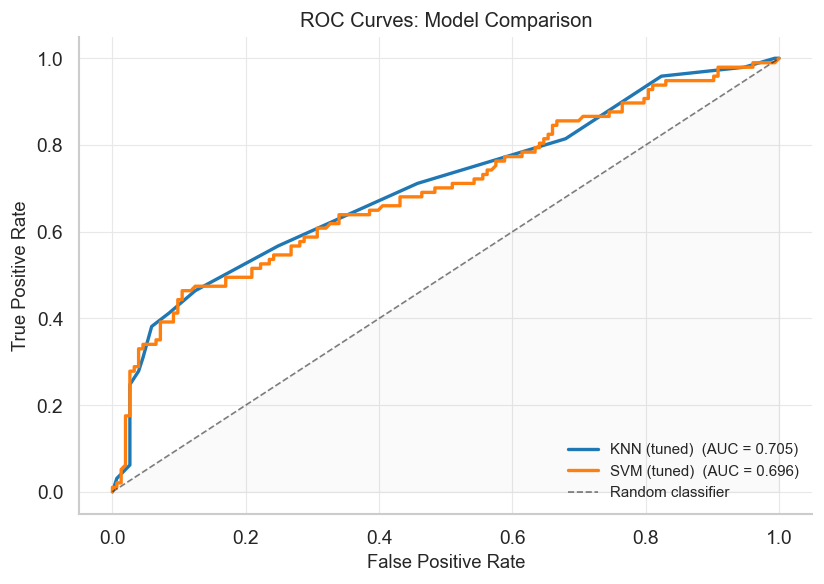

In [53]:
fig = plot_roc_curves(final_models, X_test, y_test)
plt.show()
save_figure(fig, "roc_curves", FIGURES_DIR / "final_evaluation")

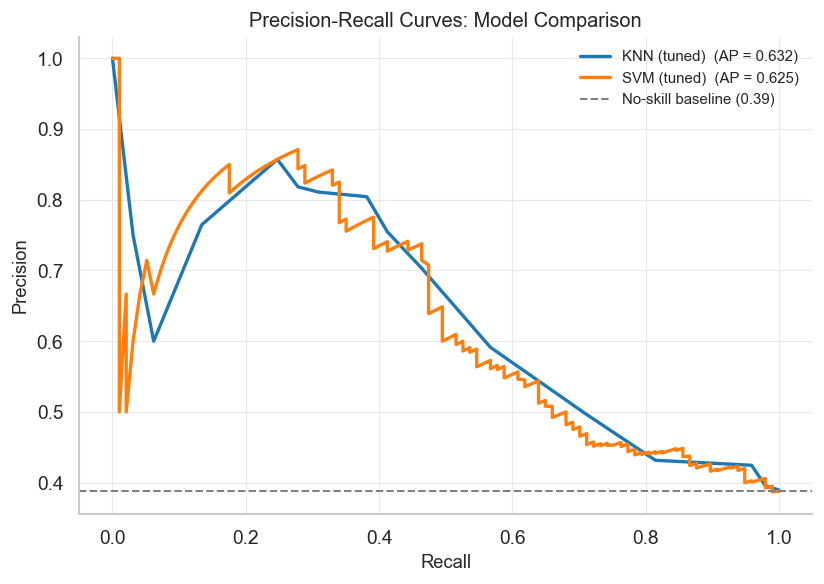

In [54]:
fig = plot_pr_curves(final_models, X_test, y_test)
plt.show()
save_figure(fig, "pr_curves", FIGURES_DIR / "final_evaluation")

Top model: KNN (tuned)


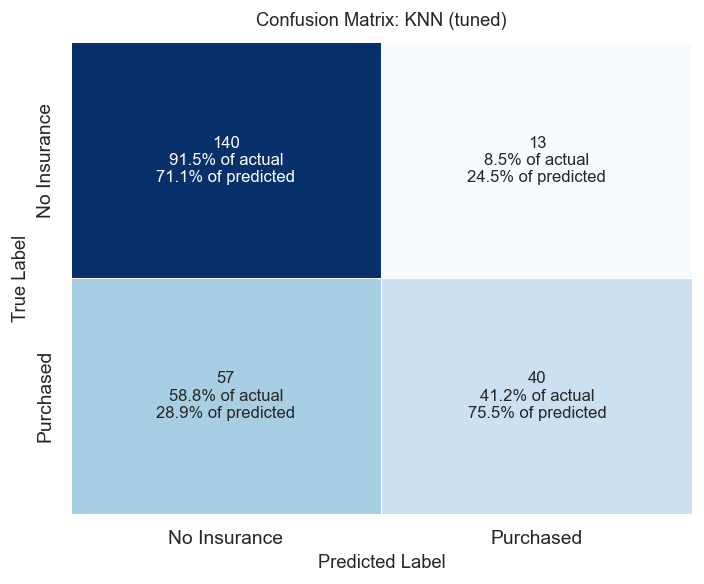

In [55]:
top_model_name = compare_final_metrics(all_metrics).index[0]
top_model      = final_models[top_model_name]
print(f"Top model: {top_model_name}")

fig = plot_confusion_matrix(
    all_metrics[top_model_name]["confusion_matrix"],
    model_name=top_model_name,
)
plt.show()
save_figure(fig, "confusion_matrix_top", FIGURES_DIR / "final_evaluation")

**Confusion matrix reading guide:**

| Cell | Meaning | Business interpretation |
|---|---|---|
| **TN** (top-left) | Correctly predicted non-buyer | Saved outreach cost |
| **FP** (top-right) | Predicted buyer, actually non-buyer | Wasted marketing contact |
| **FN** (bottom-left) | Predicted non-buyer, actually buyer | Missed sale, typically most costly |
| **TP** (bottom-right) | Correctly predicted buyer | Successful targeted contact |

In this application, **FN is typically more costly than FP**: a missed genuine buyer means a lost sale, a wasted contact is a minor cost. This suggests operating at a lower decision threshold (higher recall, lower precision) relative to the default 0.5.

---
## 13. Error Analysis and Interpretation

### 13.1 Logistic Regression: Coefficient Analysis

LR coefficients represent the change in **log-odds** of purchase per unit change in the (scaled) feature. Positive = increases purchase probability. Because features are scaled, coefficient magnitudes are comparable across variables.

In [56]:
lr_best = lr_grid_search.best_estimator_
lr_pre  = lr_best.named_steps["pre"]
lr_clf  = lr_best.named_steps["clf"]

feature_names_out = lr_pre.get_feature_names_out()
coefs = lr_clf.coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names_out, "coefficient": coefs})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)
print("LR coefficients (log-odds, scaled features):")
coef_df

LR coefficients (log-odds, scaled features):


,feature,coefficient
0,annual_income,0.424228
1,ever_travelled_abroad,0.303385
2,family_members,0.147216
3,age,0.109104
4,frequent_flyer,0.071921
5,employment_type_Private Sector/Self Employed,0.039990
6,chronic_diseases,-0.034103
7,graduate_or_not,-0.041717


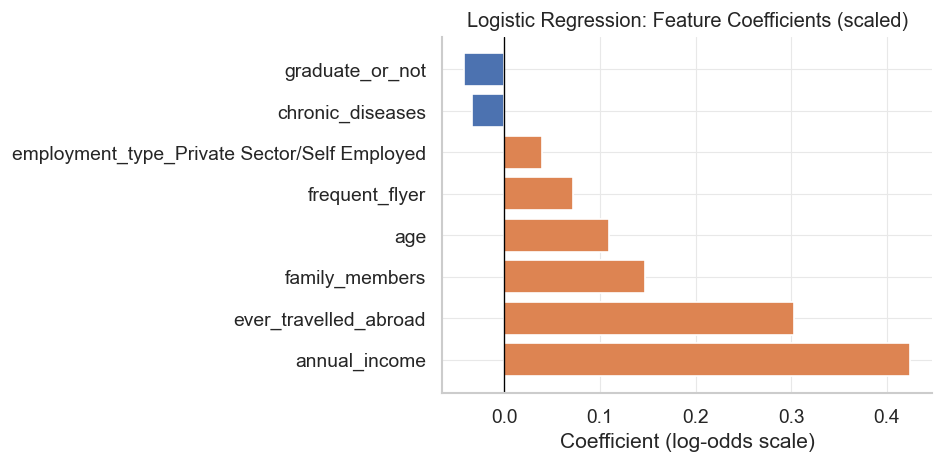

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds scale)")
ax.set_title("Logistic Regression: Feature Coefficients (scaled)", fontsize=12)
plt.tight_layout()
plt.show()
save_figure(fig, "lr_coefficients", FIGURES_DIR / "error_analysis")

**Finding:**
- Features with large positive coefficients are the strongest positive predictors in the LR model.
- `ever_travelled_abroad` and `frequent_flyer` (encoded as Yes=1) are expected to dominate, consistent with EDA.
- `annual_income` should show a meaningful positive coefficient.
- `chronic_diseases` is expected to be near-zero, consistent with the weak association found in categorical EDA.

These are associations in the regularised training data, not causal effects.

**RF importance note:** Mean impurity decrease favours high-cardinality features (like `annual_income`) and features that appear early in deep trees. Use alongside LR coefficients and EDA correlations rather than in isolation for a more robust picture of feature relevance.

### 13.2 Learning Curve: Overfitting Check

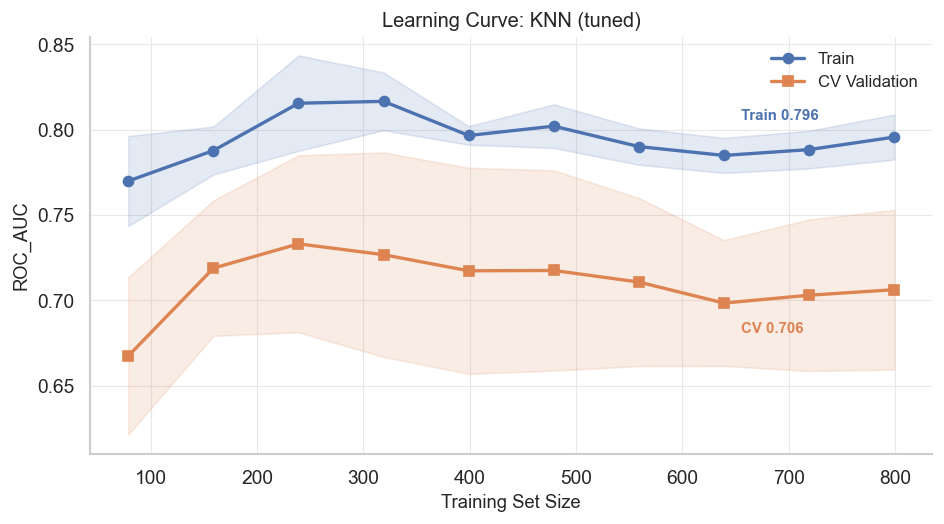

In [58]:
fig = plot_learning_curve(
    top_model, X_train, y_train,
    model_name=top_model_name,
    cv=5, scoring="roc_auc",
)
plt.show()
save_figure(fig, "learning_curve", FIGURES_DIR / "error_analysis")

**Learning curve findings:**
- **Large train-vs-validation gap**: overfitting; more data or stronger regularisation needed.
- **Both curves plateau at a low score**: underfitting; more features or a more expressive model needed.
- **Curves converge at a high score**: well-fitted; adding data gives diminishing returns.

### 13.3 Precision-Recall Tradeoff

The default 0.5 threshold is rarely the business-optimal operating point, and the PR curve in Section 13 provides the full frontier, and choosing the operating point requires knowing the ratio between the cost of a missed buyer (FN) and the cost of a wasted contact (FP), a business decision that cannot be resolved from data alone. The model should be handed to the business team with the PR curve and guidance on how to set the threshold.

---
## 14. Dashboard

Interactive executive dashboard summarizing the full ML pipeline: data profile, model comparison, feature importance, and final evaluation.

In [59]:
from travel_insurance.plots import dashboard_travel_insurance

dashboard_path = FIGURES_DIR / "dashboard_travel_insurance.html"

fig = dashboard_travel_insurance(
    df,
    cv_results,
    all_metrics,
    final_models,
    X_test,
    y_test,
    coef_df,
    out_path=dashboard_path,
)
fig.show()

---
## 15. Conclusion, Limitations, and Recommendations

### Conclusion

The goal was to predict whether a customer would purchase travel insurance, using demographic and travel history features. SVM and KNN were the strongest models, both outperforming the logistic regression baseline. The most important predictors were annual income and international travel experience, consistent with what the EDA and statistical tests showed.

The model is trained on a convenience sample of existing customers from 2019. It should not be used to make claims about the general population, and it cannot explain why customers buy, only which profiles are associated with higher purchase rates.

### Limitations

- **Sample scope**: the data covers one company in 2019. Behaviour may have shifted post-pandemic, and the findings do not generalise beyond this customer base.
- **No causality**: all associations are observational. Changing a feature value for a customer would not necessarily change their purchase probability.
- **Missing features**: purchase history, number of trips, destination, and sales channel are not available. These would likely be more predictive than what is currently in the dataset.
- **Income granularity**: income is rounded to the nearest Rs 50,000, which introduces noise around breakpoint values.

### Recommendations

- **Set the threshold using the PR curve.** The default 0.5 threshold is not the business-optimal point. The company should decide the acceptable ratio between a missed sale and a wasted contact, then read the threshold off the PR curve accordingly.
- **Collect richer features.** Prior insurance history, number of trips per year, and destination type are the highest-value additions. They would likely improve predictive power more than any modelling change.
- **Retrain periodically.** Customer behaviour shifts over time. The model should be retrained after each insurance offering cycle to stay calibrated.
- **Test gradient boosting.** XGBoost or LightGBM are the natural next step for tabular binary classification and would serve as a strong production baseline.